In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data if using CSV
df = pd.read_csv("../Ontrac_data.csv")

df.columns = df.columns.str.strip()

# Convert data types
df["Invoice_Date"] = pd.to_datetime(df["Invoice_Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

# Set visualization style
sns.set_theme(style="whitegrid")

# Check the data
print(df.head())
print(df.info())

  Invoice_Date               Client                      Products    Amount  \
0   2025-09-02              NOVAQUA      SIKACERAM 80I WHITE+GREY  21420.00   
1   2025-09-08   MY DE CONSTRUCTION           REBAR 08 TOR FE 500  11144.00   
2   2025-09-17          TERRASTRUCT  CEMENT CPJ35 (21 T +19 bags)  36790.00   
3   2025-09-22  STE DERRAB LISSAKAN    SIKACERAM 80I WHITE + GREY   4998.68   
4   2025-09-23  STE DERRAB LISSAKAN    WOOD TALK LOUVERS 200X1200   4999.60   

                      Bank_Document  
0                 TRANSFER RECEIVED  
1  COLLECTION OF 1 BILL OF EXCHANGE  
2                 TRANSFER RECEIVED  
3           OFF-BRANCH CASH DEPOSIT  
4           OFF-BRANCH CASH DEPOSIT  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Invoice_Date   146 non-null    datetime64[ns]
 1   Client         147 non-null    obje

## 1. Which products generate the highest revenue?

In [6]:
product_revenue = (
    df.groupby("Products")["Amount"]
      .sum()
      .sort_values(ascending=False)
      .to_frame(name="Revenue")
)

product_revenue["Pct"] = (
    product_revenue["Revenue"] / product_revenue["Revenue"].sum() * 100
)

print(product_revenue)

                                           Revenue        Pct
Products                                                     
CIMARPRO 35 (27 T)                       447555.00  17.010303
CEMENT CPJ35 (27 T)                      322380.00  12.252754
CEMENT CPJ35 (28 T)                      199230.00   7.572170
CEMENT CPJ35 (27 T)+ PROLIDAL            160920.00   6.116115
WEBERCOL CLASSIC WHITE                    97884.97   3.720332
CEMENT CPJ35 (29 T)                       86420.00   3.284580
CIMARPRO 45 (27 T)                        82620.00   3.140153
CIMARPRO 35 (26 T)                        80000.00   3.040574
SIKACERAM 100M+80I                        78519.00   2.984286
SIKACERAM 80I WHITE+GREY                  66220.00   2.516835
SIKACERAM 80I GREY + PROLIDAL             54185.00   2.059419
SIKACERAM 80I + HAMRI ADHESIVE            48500.00   1.843348
SIKACERAM 80I WHITE+GREY+REBAR 10 TOR     45600.00   1.733127
CIMARPRO 35                               42080.00   1.599342
CIMARPRO

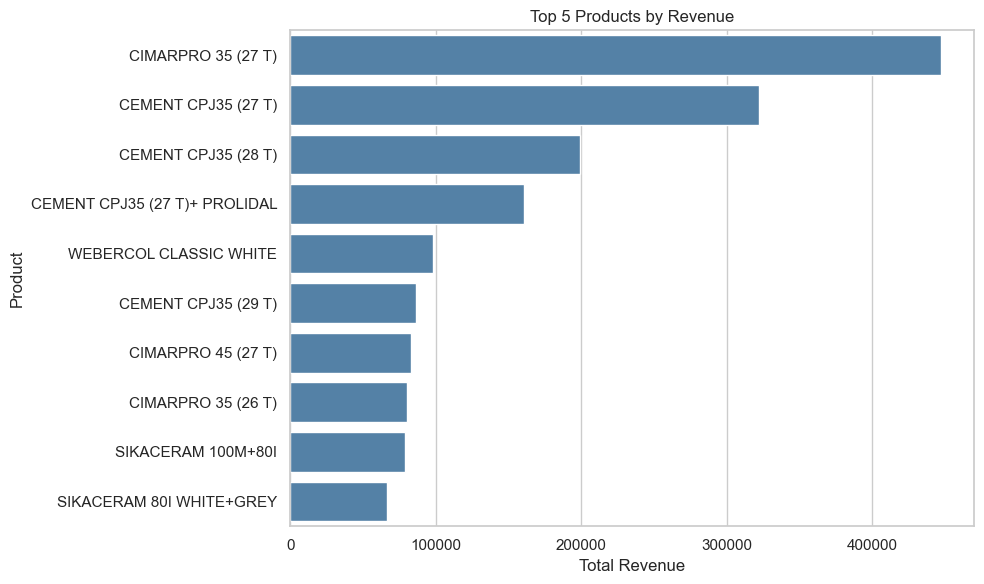

In [13]:
top_5_revenue = product_revenue.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_5_revenue["Revenue"],
    y=top_5_revenue.index,
    color="steelblue"
)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 2. Which products have the highest average invoice value?

In [10]:
avg_invoice = (
    df.groupby("Products")["Amount"]
      .mean()
      .sort_values(ascending=False)
)

avg_invoice

Products
SIKACERAM 80I + HAMRI ADHESIVE             48500.000000
SIKACERAM 80I WHITE+GREY+REBAR 10 TOR      45600.000000
CEMENT CPJ35 (29 T)                        43210.000000
CIMARPRO 35 (27 T)+ REBAR 05 SMOOTH        42080.000000
CIMARPRO 35                                42080.000000
CEMENT CPJ35 (27 T)+SIKACERAM 80I WHITE    41720.000000
CEMENT CPJ35+ REBAR 12 TOR                 41600.000000
CEMENT CPJ35+REBAR 12 TOR                  41445.000000
CIMARPRO 45 (27 T)                         41310.000000
CIMARPRO 35 (27 T)                         40686.818182
CIMARPRO 45+35                             40345.000000
CEMENT CPJ35 (27 T)                        40297.500000
CEMENT CPJ35 (27 T)+ PROLIDAL              40230.000000
CEMENT CPJ35                               40000.000000
CIMARPRO 35 (26 T)                         40000.000000
CEMENT CPJ35 (28 T)                        39846.000000
CEMENT CPJ35 (21 T +19 bags)               36790.000000
SIKACERAM 80I WHITE+GREY               

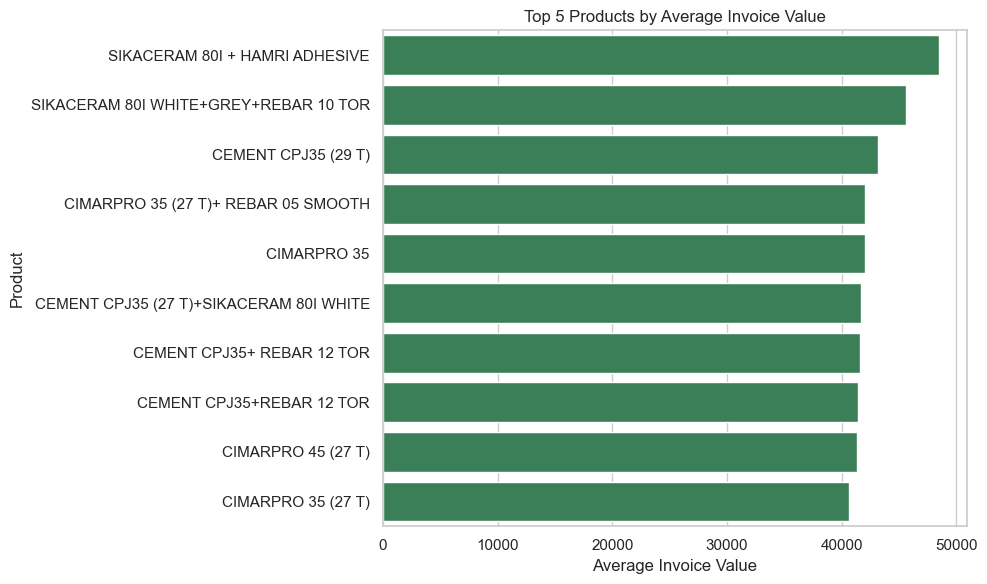

In [12]:
top_5_avg_invoice = avg_invoice.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_5_avg_invoice.values,
    y=top_5_avg_invoice.index,
    color="seagreen"
)

plt.title("Top 5 Products by Average Invoice Value")
plt.xlabel("Average Invoice Value")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 3. Which products have the largest variation in transaction amounts?

In [14]:
amount_variation = (
    df.groupby("Products")["Amount"]
      .std()
      .sort_values(ascending=False)
)

amount_variation

Products
SIKACERAM 80I WHITE+GREY                   16532.156544
WEBERCOL CLASSIC GREY+WHITE                12328.406730
SIKACERAM 100M+80I                         12151.010979
WEBERCOL CLASSIC+JUNTA FINA                 7898.151683
SIKACERAM 80I GREY + PROLIDAL               6409.922971
WEBERCOL CLASSIC WHITE                      5480.625942
CEMENT CPJ35 (28 T)                         4190.391390
SIKACERAM 80I+HAMRI ADHESIVE                3953.095046
REBAR 05 SMOOTH                             2262.741700
SIKACERAM 80I WHITE                         1743.599228
HAMRI ADHESIVE GREY C1                       777.591185
SIKACERAM 100M WHITE                         490.279558
WEBERCOL CLASSIC GREY                        467.583651
CIMARPRO 35 (27 T)                           461.520708
HAMRI ADHESIVE GREY C1 25KG                  212.132034
CEMENT CPJ35 (27 T)                          124.985713
SIKACERAM 80I WHITE + GREY                     0.433590
GURU WATERSTOP MAT (30 m2)             

In [16]:
variation_summary = (
    df.groupby("Products")["Amount"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median",
          Std_Dev="std",
          Minimum="min",
          Maximum="max"
      )
      .sort_values("Std_Dev", ascending=False)
)

variation_summary

,Count,Mean,Median,Std_Dev,Minimum,Maximum
Products,,,,,,
SIKACERAM 80I WHITE+GREY,2,33110.000000,33110.00,16532.156544,21420.00,44800.00
WEBERCOL CLASSIC GREY+WHITE,2,11442.500000,11442.50,12328.406730,2725.00,20160.00
SIKACERAM 100M+80I,7,11217.000000,4110.40,12151.010979,4110.40,30000.00
WEBERCOL CLASSIC+JUNTA FINA,3,8880.000000,4320.00,7898.151683,4320.00,18000.00
SIKACERAM 80I GREY + PROLIDAL,2,27092.500000,27092.50,6409.922971,22560.00,31625.00
WEBERCOL CLASSIC WHITE,16,6117.810625,4550.72,5480.625942,2160.00,24900.00
CEMENT CPJ35 (28 T),5,39846.000000,41720.00,4190.391390,32350.00,41720.00
SIKACERAM 80I+HAMRI ADHESIVE,9,3966.222222,2592.00,3953.095046,2592.00,14500.00
REBAR 05 SMOOTH,2,4400.000000,4400.00,2262.741700,2800.00,6000.00


## 4. Are certain products consistently associated with high-value invoices?

In [17]:
high_value_analysis = (
    df.groupby("Products")["Amount"]
      .agg(
          Transaction_Count="count",
          Average_Invoice="mean",
          Median_Invoice="median",
          Minimum_Invoice="min",
          Maximum_Invoice="max",
          Std_Dev="std"
      )
      .sort_values("Average_Invoice", ascending=False)
)
high_value_analysis

,Transaction_Count,Average_Invoice,Median_Invoice,Minimum_Invoice,Maximum_Invoice,Std_Dev
Products,,,,,,
SIKACERAM 80I + HAMRI ADHESIVE,1,48500.000000,48500.00,48500.00,48500.00,NaN
SIKACERAM 80I WHITE+GREY+REBAR 10 TOR,1,45600.000000,45600.00,45600.00,45600.00,NaN
CEMENT CPJ35 (29 T),2,43210.000000,43210.00,43210.00,43210.00,0.000000
CIMARPRO 35 (27 T)+ REBAR 05 SMOOTH,1,42080.000000,42080.00,42080.00,42080.00,NaN
CIMARPRO 35,1,42080.000000,42080.00,42080.00,42080.00,NaN
CEMENT CPJ35 (27 T)+SIKACERAM 80I WHITE,1,41720.000000,41720.00,41720.00,41720.00,NaN
CEMENT CPJ35+ REBAR 12 TOR,1,41600.000000,41600.00,41600.00,41600.00,NaN
CEMENT CPJ35+REBAR 12 TOR,1,41445.000000,41445.00,41445.00,41445.00,NaN
CIMARPRO 45 (27 T),2,41310.000000,41310.00,41310.00,41310.00,0.000000


<Figure size 1200x700 with 0 Axes>

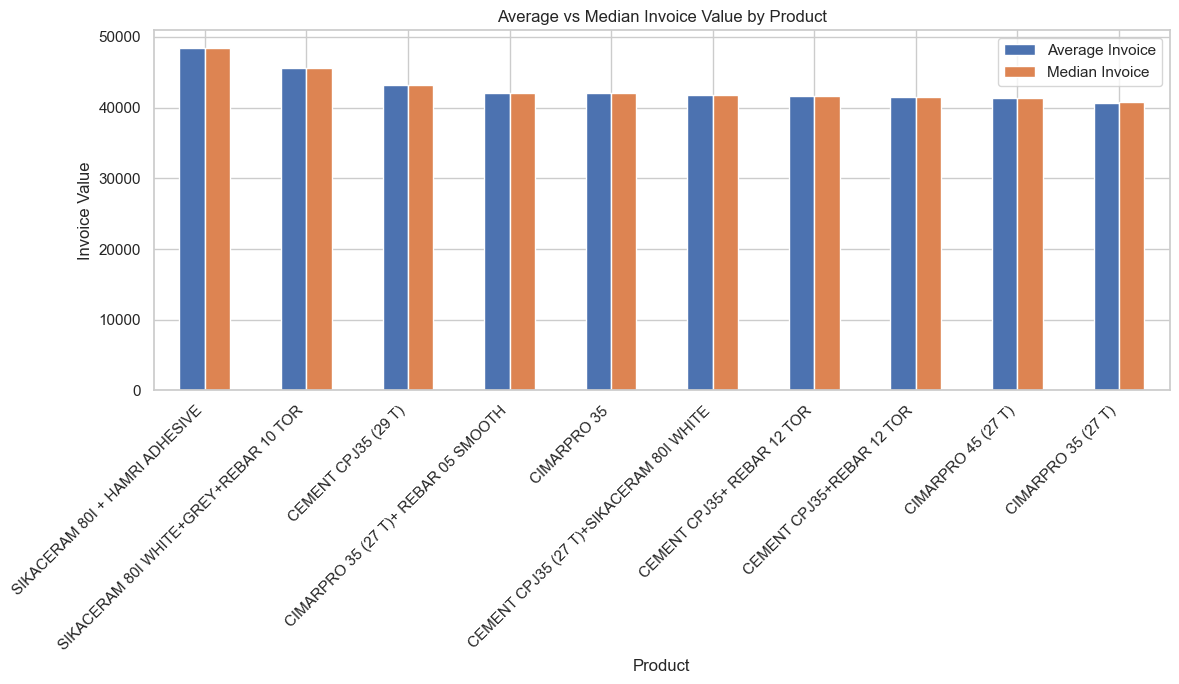

In [23]:
plt.figure(figsize=(12, 7))

high_value_plot = high_value_analysis[["Average_Invoice", "Median_Invoice"]].head(10)


high_value_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Average vs Median Invoice Value by Product")
plt.xlabel("Product")
plt.ylabel("Invoice Value")
plt.xticks(rotation=45, ha="right")
plt.legend(["Average Invoice", "Median Invoice"])
plt.tight_layout()
plt.show()

## 5. Which products have the highest potential for sales growth?

In [26]:
""" High frequency + high average value → strong products
    High frequency + low average value → volume opportunity
    Low frequency + high average value → premium opportunity
    Low frequency + low average value → low priority            """

' High frequency + high average value → strong products\n    High frequency + low average value → volume opportunity\n    Low frequency + high average value → premium opportunity\n    Low frequency + low average value → low priority            '

In [24]:
growth_analysis = (
    df.groupby("Products")["Amount"]
      .agg(
          Transaction_Count="count",
          Average_Invoice="mean",
          Total_Revenue="sum"
      )
)

# Calculate overall averages
avg_frequency = growth_analysis["Transaction_Count"].mean()
avg_invoice = growth_analysis["Average_Invoice"].mean()

# Create product categories
def classify_product(row):
    if (
        row["Transaction_Count"] >= avg_frequency
        and row["Average_Invoice"] >= avg_invoice
    ):
        return "Strong Performer"

    elif (
        row["Transaction_Count"] >= avg_frequency
        and row["Average_Invoice"] < avg_invoice
    ):
        return "Volume Opportunity"

    elif (
        row["Transaction_Count"] < avg_frequency
        and row["Average_Invoice"] >= avg_invoice
    ):
        return "Premium Opportunity"

    else:
        return "Low Priority"


growth_analysis["Category"] = growth_analysis.apply(
    classify_product,
    axis=1
)

growth_analysis

,Transaction_Count,Average_Invoice,Total_Revenue,Category
Products,,,,
CEMENT CPJ35,1,40000.000000,40000.00,Premium Opportunity
CEMENT CPJ35 (21 T +19 bags),1,36790.000000,36790.00,Premium Opportunity
CEMENT CPJ35 (27 T),8,40297.500000,322380.00,Strong Performer
CEMENT CPJ35 (27 T)+ PROLIDAL,4,40230.000000,160920.00,Strong Performer
CEMENT CPJ35 (27 T)+SIKACERAM 80I WHITE,1,41720.000000,41720.00,Premium Opportunity
CEMENT CPJ35 (28 T),5,39846.000000,199230.00,Strong Performer
CEMENT CPJ35 (29 T),2,43210.000000,86420.00,Premium Opportunity
CEMENT CPJ35+ REBAR 12 TOR,1,41600.000000,41600.00,Premium Opportunity
CEMENT CPJ35+REBAR 12 TOR,1,41445.000000,41445.00,Premium Opportunity


In [29]:
## Find the strongest products
strong_products = growth_analysis[
    growth_analysis["Category"] == "Strong Performer"
]

print("Strong performing products:")
strong_products

Strong performing products:


,Transaction_Count,Average_Invoice,Total_Revenue,Category
Products,,,,
CEMENT CPJ35 (27 T),8,40297.500000,322380.0,Strong Performer
CEMENT CPJ35 (27 T)+ PROLIDAL,4,40230.000000,160920.0,Strong Performer
CEMENT CPJ35 (28 T),5,39846.000000,199230.0,Strong Performer
CIMARPRO 35 (27 T),11,40686.818182,447555.0,Strong Performer


In [30]:
## Find volume opportunities
volume_opportunities = growth_analysis[
    growth_analysis["Category"] == "Volume Opportunity"
]

print("Volume opportunities:")
volume_opportunities

Volume opportunities:


,Transaction_Count,Average_Invoice,Total_Revenue,Category
Products,,,,
GURU WATERSTOP MAT (30 m2),4,4800.000000,19200.00,Volume Opportunity
SIKACERAM 100M GREY,4,4999.280000,19997.12,Volume Opportunity
SIKACERAM 100M+80I,7,11217.000000,78519.00,Volume Opportunity
SIKACERAM 80I WHITE,7,4338.102857,30366.72,Volume Opportunity
SIKACERAM 80I WHITE + GREY,5,4999.440000,24997.20,Volume Opportunity
SIKACERAM 80I+HAMRI ADHESIVE,9,3966.222222,35696.00,Volume Opportunity
WEBERCOL CLASSIC GREY,9,4391.366667,39522.30,Volume Opportunity
WEBERCOL CLASSIC WHITE,16,6117.810625,97884.97,Volume Opportunity
WEBERCOL CLASSIC+JUNTA FINA,3,8880.000000,26640.00,Volume Opportunity


In [31]:
## Find premium opportunities
premium_opportunities = growth_analysis[
    growth_analysis["Category"] == "Premium Opportunity"
]

print("Premium opportunities:")
premium_opportunities

Premium opportunities:


,Transaction_Count,Average_Invoice,Total_Revenue,Category
Products,,,,
CEMENT CPJ35,1,40000.0,40000.0,Premium Opportunity
CEMENT CPJ35 (21 T +19 bags),1,36790.0,36790.0,Premium Opportunity
CEMENT CPJ35 (27 T)+SIKACERAM 80I WHITE,1,41720.0,41720.0,Premium Opportunity
CEMENT CPJ35 (29 T),2,43210.0,86420.0,Premium Opportunity
CEMENT CPJ35+ REBAR 12 TOR,1,41600.0,41600.0,Premium Opportunity
CEMENT CPJ35+REBAR 12 TOR,1,41445.0,41445.0,Premium Opportunity
CIMARPRO 35,1,42080.0,42080.0,Premium Opportunity
CIMARPRO 35 (15 T),1,23328.0,23328.0,Premium Opportunity
CIMARPRO 35 (26 T),2,40000.0,80000.0,Premium Opportunity
